## Simple MultiAI Agent Architecture

## Simple Multi-Agent Architecture

In this workflow, multiple specialized agents collaborate to complete a task. Each agent has a specific responsibility, and the task flows sequentially through the agents until the final result is produced.

The system contains two main agents:

- **Researcher Agent** – gathers information using tools such as web search.
- **Writer Agent** – summarizes and organizes the findings into a clear response.

If the researcher needs external information, it calls a tool (e.g., web search). After the research is complete, the results are passed to the writer agent to generate the final summary.

---

### Step-by-Step Process

1. **User Query**  
   The process starts when a user submits a request or question.

2. **Researcher Agent**  
   The researcher agent analyzes the query and determines whether additional information is required.

3. **Tool Decision**
   - If more information is needed, the agent calls a tool such as a **web search API**.
   - The tool retrieves relevant data and returns it to the researcher.

4. **Research Iteration**  
   The researcher may repeat tool usage until enough information is gathered.

5. **Writer Agent**  
   Once sufficient information is collected, the writer agent reviews the conversation and research results and produces a **structured summary**.

6. **Final Output**  
   The system returns the final summarized response to the user.

---

### Key Idea

This architecture demonstrates a **simple multi-agent system**, where different agents handle different responsibilities:

- **Research Agent → Information gathering**
- **Writer Agent → Content synthesis**

By separating responsibilities, the system becomes **more modular, scalable, and easier to extend** with additional agents or tools.

---

### Workflow Diagram

```text
User
 ↓
Researcher
 ↓
Tool needed?
 ↓
Yes → Tools → Researcher
 ↓
No
 ↓
Writer
 ↓
END

In [1]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [3]:
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

In [4]:
## Define the state
class AgentState(MessagesState):
    next_agent:str #which agent should go next 

In [5]:
# Create simple tools
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    # Using Tavily for web search
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    # Simple summary generation
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [6]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x116b65a90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x116fc8890>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
def researcher_agent(state: AgentState):

    messages = state["messages"]

    system_msg = SystemMessage(
        content="You are a research assistant. Use the search_web tool when needed to find information."
    )

    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)

    # Check if tool call exists
    if hasattr(response, "tool_calls") and response.tool_calls:
        next_node = "tools"
    else:
        next_node = "writer"

    return {
        "messages": [response],
        "next_agent": next_node
    }

In [8]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""
    
    messages = state["messages"]
    
    # Add system message
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")
    
    # Simple completion without tools
    response = llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

In [9]:
# Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        # Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response
    
    # No tools to execute
    return state

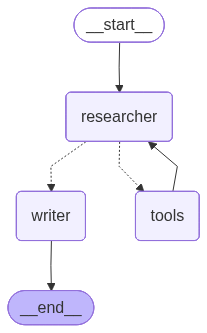

In [10]:

tool_node = ToolNode([search_web])
def router(state: AgentState):
    return state["next_agent"]

workflow = StateGraph(AgentState)

workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)
workflow.add_node("tools", tool_node)

workflow.set_entry_point("researcher")

workflow.add_conditional_edges(
    "researcher",
    router,
    {
        "tools": "tools",
        "writer": "writer"
    }
)

workflow.add_edge("tools", "researcher")
workflow.add_edge("writer", END)

final_workflow = workflow.compile()
final_workflow

In [12]:
from langchain_core.messages import HumanMessage

response = final_workflow.invoke({
    "messages": [HumanMessage(content="Research about the use case of agentic AI in business")]
})

In [14]:
response["messages"][-1].content
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Research about the use case of agentic AI in business
================================== Ai Message ==================================
Tool Calls:
  search_web (fc_675d7b42-d85d-4946-972b-9e1a0de39db3)
 Call ID: fc_675d7b42-d85d-4946-972b-9e1a0de39db3
  Args:
    query: agentic AI use cases in business
================================= Tool Message =================================
Name: search_web

[{'title': '12 agentic AI use cases: How AI improves business ...', 'url': 'https://nexos.ai/blog/agentic-ai-use-cases/', 'content': 'Agentic AI is transforming Business Process Management (BPM) by autonomously monitoring, optimizing, and executing workflows. For example, AI agents can convert meeting notes into project tickets or trigger supplier orders based on predictive analytics, streamlining operations and reducing manual intervention.\n\nIn business intelligence (BI), agentic AI improves data accessibil